# Sazonalidade e calendario

**Objetivo:** investigar se a serie apresenta padroes recorrentes associados ao calendario. Em series de internacoes, esse tipo de analise costuma revelar efeitos de inverno, de dia util/fim de semana, de feriados e de concentracao em certos periodos do ano.

Nesta etapa vamos analisar a serie por:
- ano;
- mes;
- semana epidemiologica;
- dia da semana;
- fim de semana;
- feriados e datas moveis relevantes;
- estacoes do ano.

Antes dos graficos, vamos enriquecer o dataframe com variaveis de calendario que serao reutilizadas nas proximas etapas.

## Configurações e importações
Bibliotecas usadas e parâmetros gerais.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

## Consumindo o datasets (Internações)

**Objetivo:** Consumir o dataset com as quantidades de internações por doenças respiratórias da cidade do Rio de Janeiro de 2012 até 2024

In [ ]:
url_internacoes = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/IntermediaryData/DataSus/respiratory_hospitalization_time_series.parquet"

df_internacoes = pd.read_parquet(url_internacoes)

df_serie = df_internacoes.copy()

df_serie["data_dia"] = pd.to_datetime(df_serie["data_dia"], errors="coerce")

df_serie = df_serie.sort_values("data_dia").reset_index(drop=True)

## Sazonalidade e Calendario

In [3]:
meses = {
    1: "Jan", 2: "Fev", 3: "Mar", 4: "Abr", 5: "Mai", 6: "Jun",
    7: "Jul", 8: "Ago", 9: "Set", 10: "Out", 11: "Nov", 12: "Dez"
}

dias_semana = {
    0: "Seg", 1: "Ter", 2: "Qua", 3: "Qui", 4: "Sex", 5: "Sab", 6: "Dom"
}

ordem_estacoes = ["Verao", "Outono", "Inverno", "Primavera"]


def classificar_estacao(data):
    mes = data.month
    if mes in [12, 1, 2]:
        return "Verao"
    if mes in [3, 4, 5]:
        return "Outono"
    if mes in [6, 7, 8]:
        return "Inverno"
    return "Primavera"


# Criamos atributos de calendario que serao usados em todos os recortes seguintes.
df_serie["ano"] = df_serie["data_dia"].dt.year
df_serie["mes"] = df_serie["data_dia"].dt.month
df_serie["mes_nome"] = pd.Categorical(
    df_serie["mes"].map(meses),
    categories=list(meses.values()),
    ordered=True,
)

df_serie["dia_semana_num"] = df_serie["data_dia"].dt.dayofweek
df_serie["dia_semana_nome"] = pd.Categorical(
    df_serie["dia_semana_num"].map(dias_semana),
    categories=list(dias_semana.values()),
    ordered=True,
)

df_serie["fim_de_semana"] = df_serie["dia_semana_num"].isin([5, 6])
df_serie["fim_de_semana_label"] = np.where(df_serie["fim_de_semana"], "Fim de semana", "Dia util")
df_serie["estacao"] = pd.Categorical(
    df_serie["data_dia"].apply(classificar_estacao),
    categories=ordem_estacoes,
    ordered=True,
)

# Semana epidemiologica com inicio no domingo.
ref_epi = (df_serie["data_dia"] + pd.Timedelta(days=1)).dt.isocalendar()
df_serie["ano_epi"] = ref_epi.year.astype(int)
df_serie["semana_epi"] = ref_epi.week.astype(int)

# Removendo colunas da rodada anterior para que a celula possa ser executada mais de uma vez sem duplicar informacao.
df_serie = df_serie.drop(columns=["nome_data_especial", "categoria_data_especial", "is_data_especial"], errors="ignore")

display(
    df_serie[
        [
            "data_dia",
            "num_internacoes",
            "ano",
            "mes_nome",
            "semana_epi",
            "dia_semana_nome",
            "fim_de_semana_label",
            "estacao"
        ]
    ].head(10)
)

,data_dia,num_internacoes,ano,mes_nome,semana_epi,dia_semana_nome,fim_de_semana_label,estacao
0,2012-01-01,490,2012,Jan,1,Dom,Fim de semana,Verao
1,2012-01-02,672,2012,Jan,1,Seg,Dia util,Verao
2,2012-01-03,462,2012,Jan,1,Ter,Dia util,Verao
3,2012-01-04,490,2012,Jan,1,Qua,Dia util,Verao
4,2012-01-05,378,2012,Jan,1,Qui,Dia util,Verao
5,2012-01-06,518,2012,Jan,1,Sex,Dia util,Verao
6,2012-01-07,280,2012,Jan,1,Sab,Fim de semana,Verao
7,2012-01-08,378,2012,Jan,2,Dom,Fim de semana,Verao
8,2012-01-09,448,2012,Jan,2,Seg,Dia util,Verao
9,2012-01-10,532,2012,Jan,2,Ter,Dia util,Verao


### Recorte por ano e por mes

Aqui verificamos se o nivel da serie muda de um ano para outro e em quais meses a demanda costuma ser maior ou menor. Isso ajuda a separar tendencia estrutural de sazonalidade anual.

,ano,total_anual,media_diaria,mediana_diaria,maximo_diario
0,2012,203875,557.04,504.0,1218
1,2013,168602,461.92,442.0,1079
2,2014,135760,371.95,372.0,720
3,2015,152635,418.18,385.0,1056
4,2016,103086,281.66,250.0,630
5,2017,87732,240.36,234.0,504
6,2018,96815,265.25,240.0,704


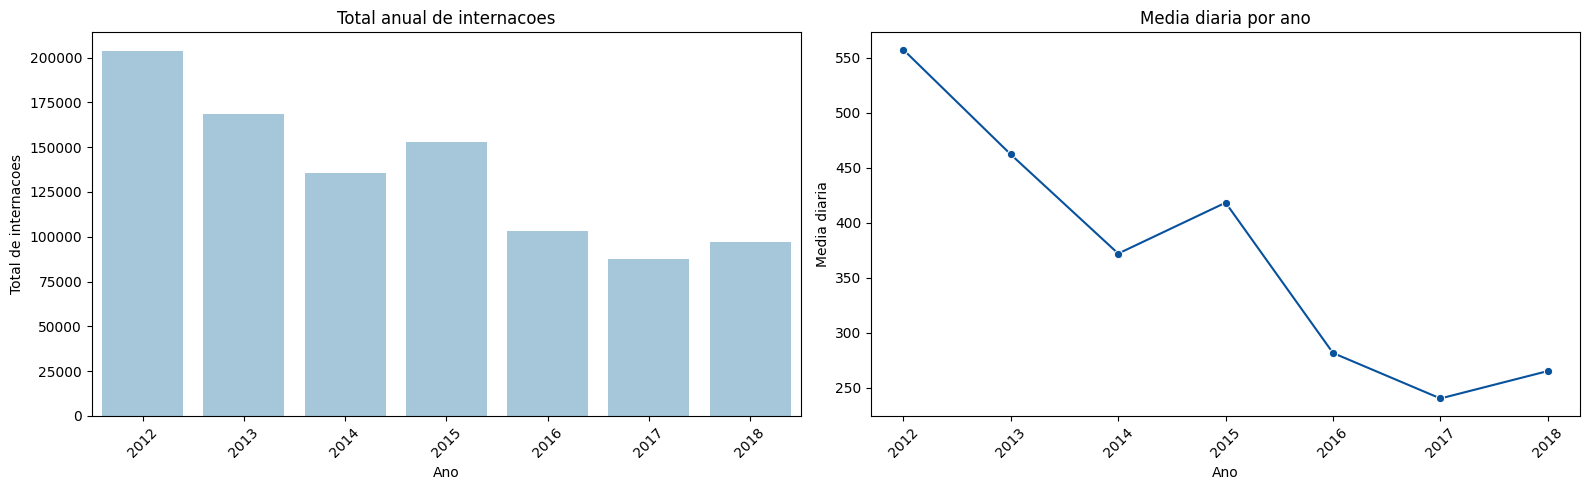

In [4]:
# Resumo anual para enxergar mudancas de nivel ao longo do tempo.
resumo_anual = (
    df_serie.groupby("ano")["num_internacoes"]
    .agg(total_anual="sum", media_diaria="mean", mediana_diaria="median", maximo_diario="max")
    .reset_index()
)

display(resumo_anual.round(2))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=resumo_anual, x="ano", y="total_anual", color="#9ecae1", ax=axes[0])
axes[0].set_title("Total anual de internacoes")
axes[0].set_xlabel("Ano")
axes[0].set_ylabel("Total de internacoes")
axes[0].tick_params(axis="x", rotation=45)

sns.lineplot(data=resumo_anual, x="ano", y="media_diaria", marker="o", color="#08519c", ax=axes[1])
axes[1].set_title("Media diaria por ano")
axes[1].set_xlabel("Ano")
axes[1].set_ylabel("Media diaria")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

,mes,media,mediana,desvio_padrao,mes_nome
0,1,271.10,240.0,124.31,Jan
1,2,270.72,262.0,137.33,Fev
2,3,336.91,320.0,164.16,Mar
3,4,483.04,442.0,209.85,Abr
4,5,554.18,504.0,236.79,Mai
5,6,497.29,465.0,195.77,Jun
6,7,441.09,416.0,167.21,Jul
7,8,375.26,352.0,140.74,Ago
8,9,340.21,319.0,141.79,Set
9,10,314.25,295.0,122.34,Out


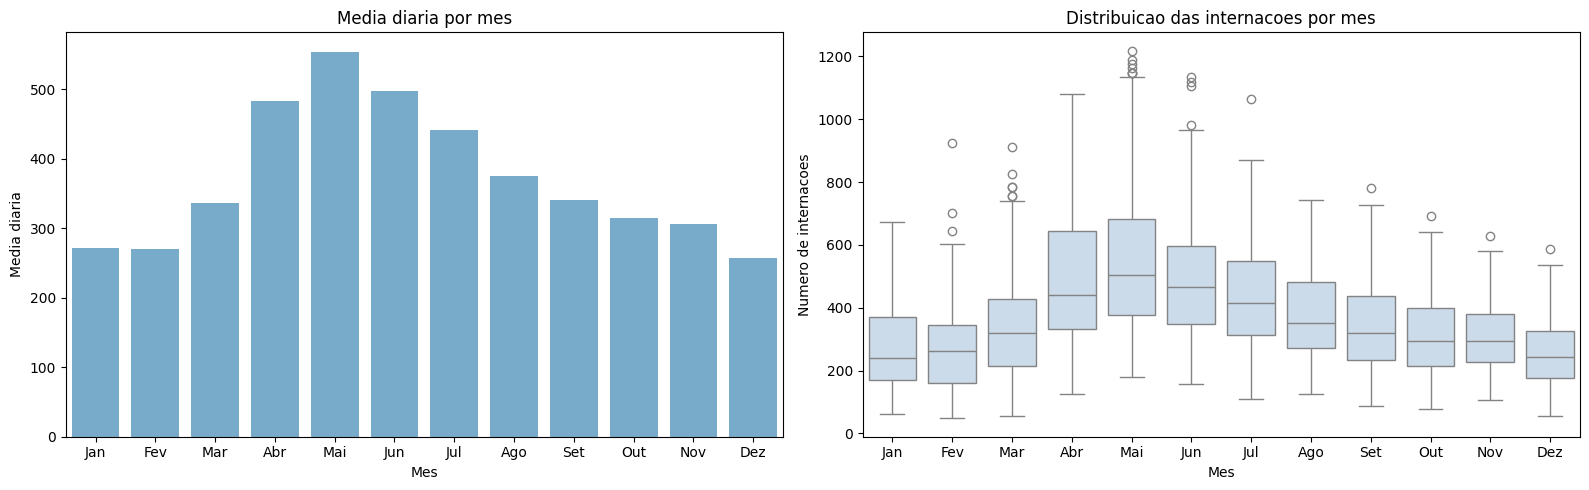

In [5]:
# Resumo mensal para identificar meses com comportamento tipicamente mais alto ou mais baixo.
resumo_mensal = (
    df_serie.groupby(["mes"])["num_internacoes"]
    .agg(media="mean", mediana="median", desvio_padrao="std")
    .reset_index()
    .sort_values("mes")
    .round(2)
)

resumo_mensal["mes_nome"] = resumo_mensal["mes"].map(meses)

display(resumo_mensal)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=resumo_mensal, x="mes_nome", y="media", color="#6baed6", ax=axes[0])
axes[0].set_title("Media diaria por mes")
axes[0].set_xlabel("Mes")
axes[0].set_ylabel("Media diaria")

sns.boxplot(data=df_serie, x="mes_nome", y="num_internacoes", color="#c6dbef", ax=axes[1])
axes[1].set_title("Distribuicao das internacoes por mes")
axes[1].set_xlabel("Mes")
axes[1].set_ylabel("Numero de internacoes")

plt.tight_layout()
plt.show()

### Recorte por semana epidemiologica

A semana epidemiologica ajuda a suavizar a leitura da sazonalidade ao longo do ano. Em saude publica, esse recorte costuma ser mais informativo do que olhar apenas o mes, porque mostra melhor o inicio, a subida e o recuo das ondas.

,semana_epi,media,mediana
0,1,284.57,264.0
1,2,281.35,280.0
2,3,270.59,234.0
3,4,248.63,221.0
4,5,252.43,240.0
5,6,240.84,231.0
6,7,278.82,276.0
7,8,272.55,264.0
8,9,308.71,312.0
9,10,305.33,308.0


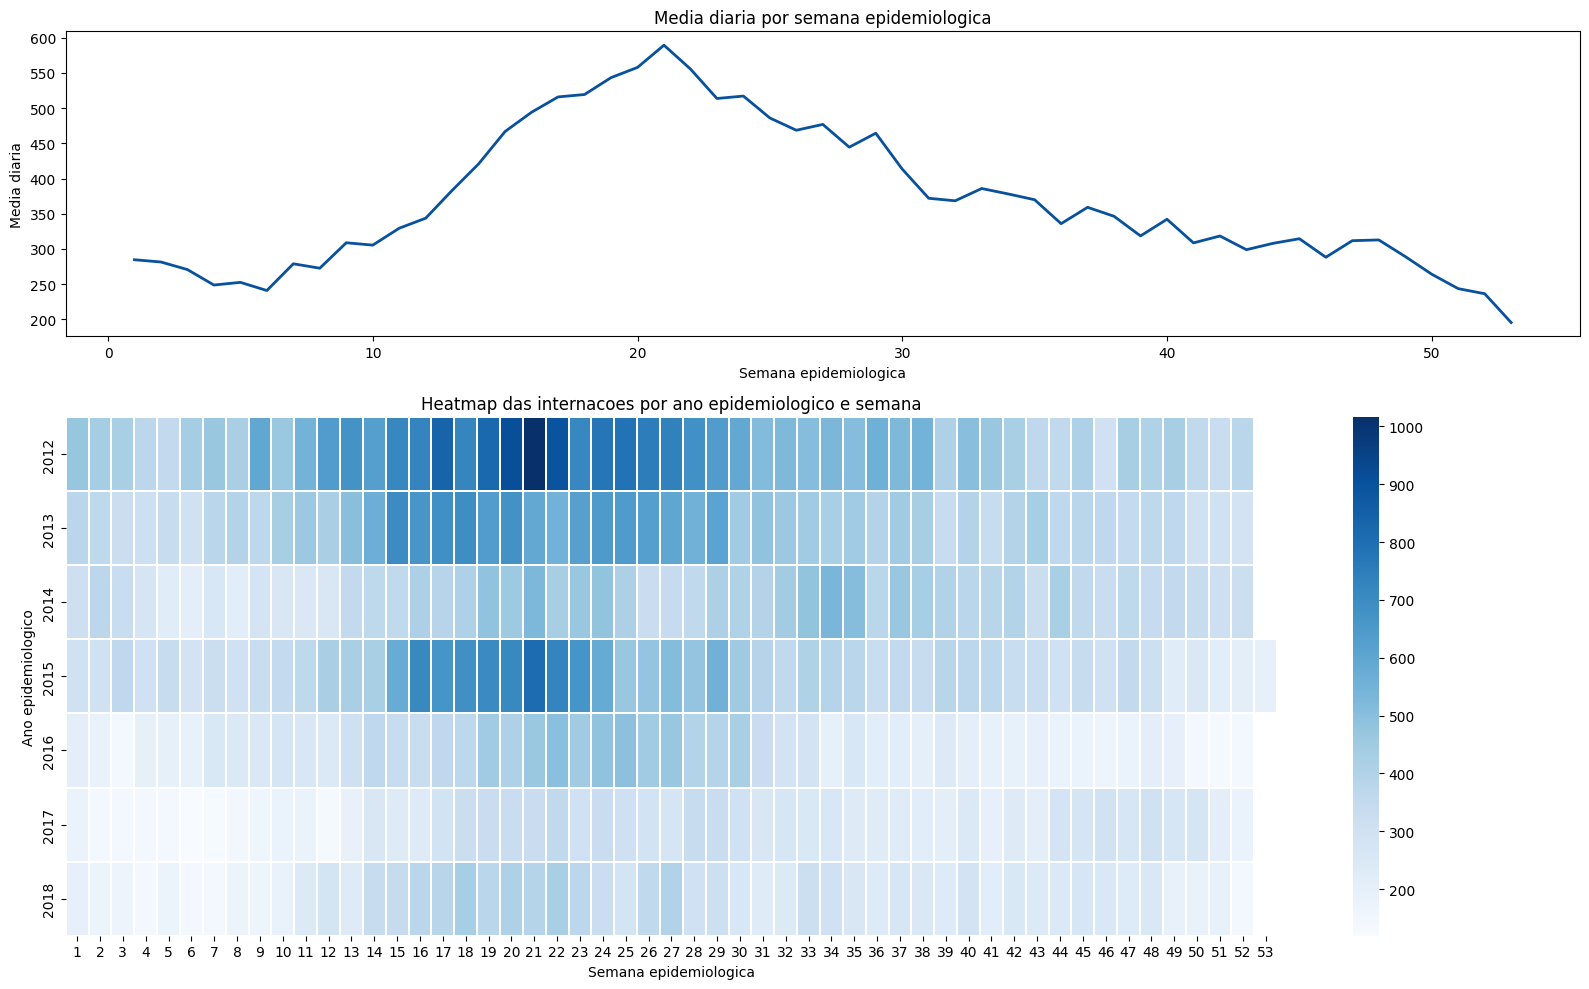

In [6]:
# Media diaria por semana epidemiologica ao longo de toda a serie.
resumo_semana_epi = (
    df_serie.groupby("semana_epi")["num_internacoes"]
    .agg(media="mean", mediana="median")
    .reset_index()
)

display(resumo_semana_epi.round(2).head(15))

# Heatmap ano x semana para observar se os picos semanais se repetem nos mesmos periodos.
heatmap_semana_epi = (
    df_serie.groupby(["ano_epi", "semana_epi"])["num_internacoes"]
    .mean()
    .reset_index()
    .pivot(index="ano_epi", columns="semana_epi", values="num_internacoes")
)

ano_min = int(df_serie["ano"].min())
ano_max = int(df_serie["ano"].max())
heatmap_semana_epi = heatmap_semana_epi.loc[(heatmap_semana_epi.index >= ano_min) & (heatmap_semana_epi.index <= ano_max)]

fig, axes = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={"height_ratios": [1, 1.7]})

sns.lineplot(data=resumo_semana_epi, x="semana_epi", y="media", color="#08519c", linewidth=2, ax=axes[0])
axes[0].set_title("Media diaria por semana epidemiologica")
axes[0].set_xlabel("Semana epidemiologica")
axes[0].set_ylabel("Media diaria")

sns.heatmap(heatmap_semana_epi, cmap="Blues", linewidths=0.1, ax=axes[1])
axes[1].set_title("Heatmap das internacoes por ano epidemiologico e semana")
axes[1].set_xlabel("Semana epidemiologica")
axes[1].set_ylabel("Ano epidemiologico")

plt.tight_layout()
plt.show()

### Dia da semana, fim de semana e datas especiais

Esse bloco ajuda a identificar padrao operacional ou assistencial. Diferencas fortes entre dias uteis e fins de semana podem refletir tanto comportamento real da demanda quanto dinamica de atendimento, registro ou adiamento de internacoes eletivas.

Nas datas especiais, combinamos feriados oficiais e algumas datas moveis relevantes para o contexto brasileiro, como Carnaval, Sexta-feira Santa e Corpus Christi.

,dia_semana_nome,media,mediana,desvio_padrao
0,Seg,431.49,394.5,209.68
1,Ter,409.74,384.0,196.32
2,Qua,419.54,400.0,189.14
3,Qui,381.10,352.0,171.64
4,Sex,387.53,350.0,182.57
5,Sab,290.87,275.0,140.13
6,Dom,276.43,251.0,133.89


,fim_de_semana_label,media,mediana,desvio_padrao
0,Dia util,405.89,376.0,191.05
1,Fim de semana,283.64,264.0,137.14


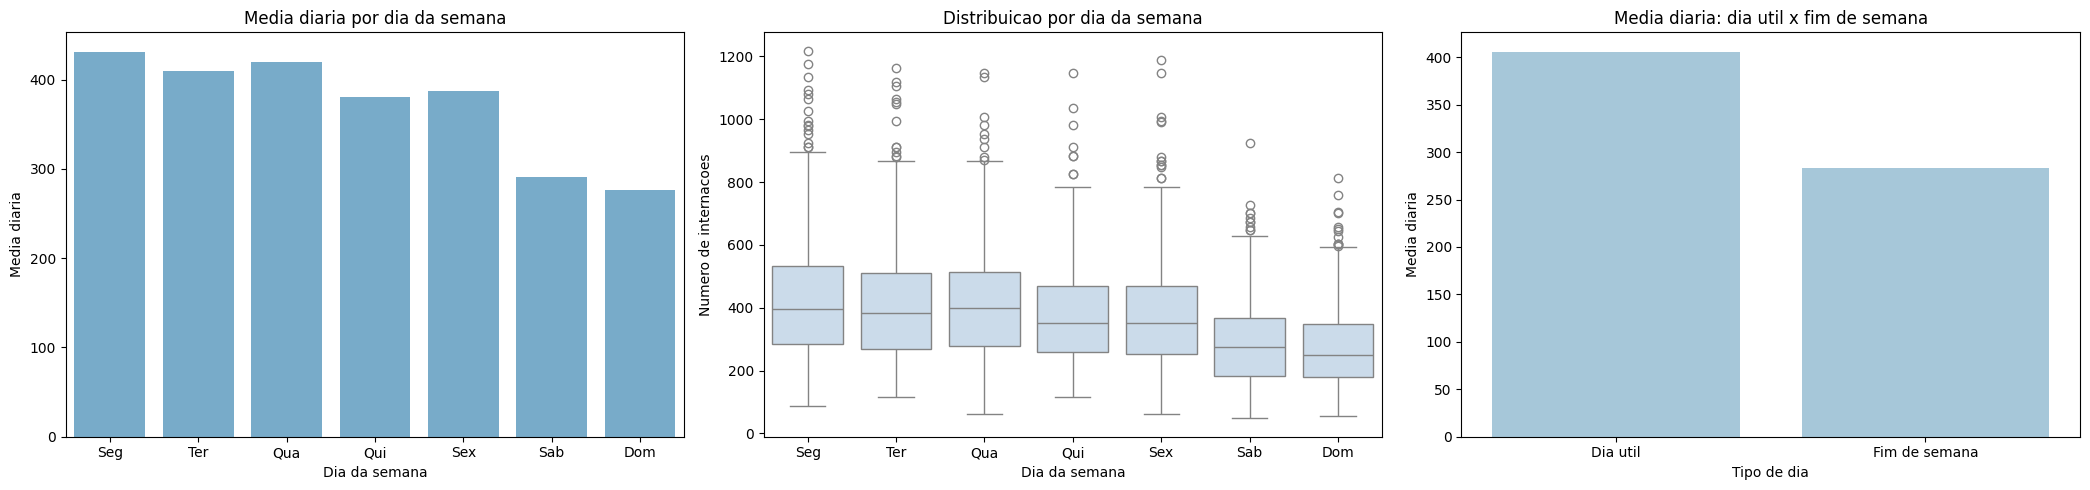

In [7]:
# Comparamos o nivel medio por dia da semana e por tipo de dia.
resumo_dia_semana = (
    df_serie.groupby(["dia_semana_num"])["num_internacoes"]
    .agg(media="mean", mediana="median", desvio_padrao="std")
    .reset_index()
    .sort_values("dia_semana_num")
)

resumo_dia_semana["dia_semana_nome"] = resumo_dia_semana["dia_semana_num"].map(dias_semana)

resumo_fim_de_semana = (
    df_serie.groupby("fim_de_semana_label")["num_internacoes"]
    .agg(media="mean", mediana="median", desvio_padrao="std")
    .reindex(["Dia util", "Fim de semana"])
    .reset_index()
)

display(resumo_dia_semana[["dia_semana_nome", "media", "mediana", "desvio_padrao"]].round(2))
display(resumo_fim_de_semana.round(2))

fig, axes = plt.subplots(1, 3, figsize=(21, 5))

sns.barplot(data=resumo_dia_semana, x="dia_semana_nome", y="media", color="#6baed6", ax=axes[0])
axes[0].set_title("Media diaria por dia da semana")
axes[0].set_xlabel("Dia da semana")
axes[0].set_ylabel("Media diaria")

sns.boxplot(data=df_serie, x="dia_semana_nome", y="num_internacoes", color="#c6dbef", ax=axes[1])
axes[1].set_title("Distribuicao por dia da semana")
axes[1].set_xlabel("Dia da semana")
axes[1].set_ylabel("Numero de internacoes")

sns.barplot(data=resumo_fim_de_semana, x="fim_de_semana_label", y="media", color="#9ecae1", ax=axes[2])
axes[2].set_title("Media diaria: dia util x fim de semana")
axes[2].set_xlabel("Tipo de dia")
axes[2].set_ylabel("Media diaria")

plt.tight_layout()
plt.show()

### Estacoes do ano

Como a serie trata de internacoes respiratorias, comparar o comportamento entre estacoes e especialmente importante. No hemisferio sul, o inverno corresponde aos meses de junho, julho e agosto.

C:\Users\João Henrique\AppData\Local\Temp\ipykernel_4972\2952343053.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_serie.groupby("estacao")["num_internacoes"]


,estacao,media,mediana,desvio_padrao
0,Verao,266.04,245.0,122.82
1,Outono,457.77,408.0,224.67
2,Inverno,437.23,408.0,176.02
3,Primavera,320.22,303.0,125.21


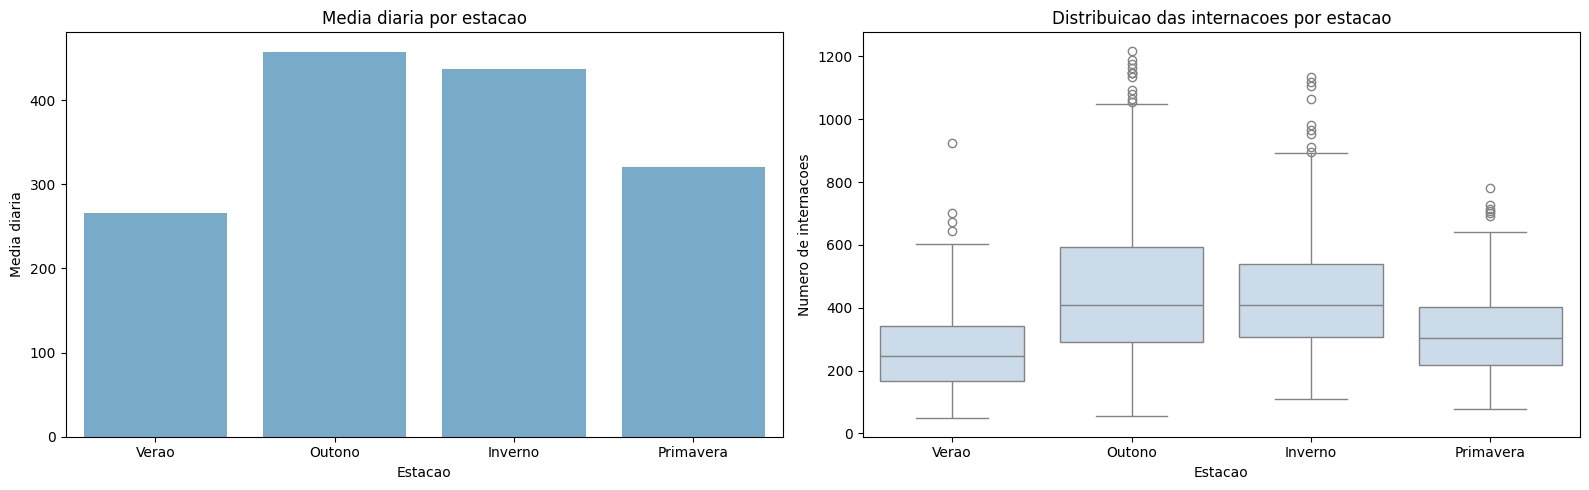

In [8]:
# Resumo por estacao para verificar efeito sazonal mais amplo do clima.
resumo_estacao = (
    df_serie.groupby("estacao")["num_internacoes"]
    .agg(media="mean", mediana="median", desvio_padrao="std")
    .reset_index()
)

display(resumo_estacao.round(2))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=resumo_estacao, x="estacao", y="media", color="#6baed6", ax=axes[0])
axes[0].set_title("Media diaria por estacao")
axes[0].set_xlabel("Estacao")
axes[0].set_ylabel("Media diaria")

sns.boxplot(data=df_serie, x="estacao", y="num_internacoes", color="#c6dbef", ax=axes[1])
axes[1].set_title("Distribuicao das internacoes por estacao")
axes[1].set_xlabel("Estacao")
axes[1].set_ylabel("Numero de internacoes")

plt.tight_layout()
plt.show()

### Resumo interpretativo dos resultados

Os recortes de calendário continuam mostrando **sazonalidade anual forte** e também **efeito semanal relevante**. No agregado por ano, a heterogeneidade entre períodos segue evidente: **2012** teve média diária de **557,0 internações**, **2013** ficou em **461,9** e **2015** em **418,2**, enquanto anos mais baixos como **2017 (240,4)** e **2018 (265,3)** aparecem em outro patamar. Isso reforça que a série combina sazonalidade com **mudanças importantes de nível ao longo do tempo**.

No recorte mensal, o padrão sazonal permanece bem marcado: as médias sobem de **março (336,9)** para **abril (483,0)**, atingem pico em **maio (554,2)** e seguem elevadas em **junho (497,3)** e **julho (441,1)**. O menor nível médio ocorreu em **dezembro (256,7)**. Assim, o mês de maior média ficou cerca de **116% acima** do mês de menor média, confirmando uma sazonalidade anual intensa.

A leitura por semana epidemiológica confirma esse comportamento. As maiores médias se concentram entre as **semanas 16 e 25**, com destaque para **19 a 22** e pico na **semana 21 (589,5)**. Isso sugere que a parte final do outono e o início do inverno concentram as ondas mais fortes de internação respiratória.

Também há um **efeito semanal consistente**: **segunda (431,5)**, **quarta (419,5)** e **terça (409,7)** ficam acima de **sábado (290,9)** e **domingo (276,4)**. Ao agrupar em dois blocos, os **dias úteis (405,9)** ficaram cerca de **43% acima** dos **fins de semana (283,6)**. Esse diferencial pode refletir tanto dinâmica assistencial real quanto efeito de registro e admissão após o fim de semana.

Na comparação por estação, o maior nível médio ocorreu no **outono (457,8)**, seguido do **inverno (437,2)**, enquanto o **verão (266,0)** foi o período de menor demanda. Portanto, a subida relevante começa antes do inverno, principalmente na transição de **março a junho**.

**Possíveis análises e consequências**
- A sazonalidade anual forte sustenta o uso de variáveis de mês, semana epidemiológica ou termos sazonais no modelo.
- O efeito dia útil/fim de semana indica que variáveis de calendário devem entrar como features obrigatórias de previsão.
- Como os picos se concentram entre **abril e julho** e nas **semanas 16 a 25**, vale testar janelas de alerta antecipado no fim do verão e início do outono.
- A diferença importante entre anos reforça a necessidade de investigar quebras estruturais e eventos anormais antes da modelagem final.